# **Kernel PCA**


## Mathematical Explanation


## Part 1:
we need a dataset :
$\mathbf{X} = \{ \mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_n \}, \mathbf{x}_i \in \mathbb{R}^d$

n = number of samples
d = number of features


## **Step 1** : Compute similarity using a kernel
## The Problem

Normal PCA works with dot products:

$$\mathbf{x}_i^\top \mathbf{x}_j$$

But dot products only capture linear relationships.

## Kernel Idea

We imagine a nonlinear mapping:

$$\phi: \mathbb{R}^d \rightarrow \mathcal{H}$$

where:

- $\mathcal{H}$ is a high (possibly infinite) dimensional space
- In that space, nonlinear patterns become linear

But we never compute $\phi(\mathbf{x})$ explicitly.

Instead, we use a kernel function:

$$k(\mathbf{x}_i, \mathbf{x}_j) = \langle \phi(\mathbf{x}_i), \phi(\mathbf{x}_j) \rangle$$

### Example: RBF (Gaussian) Kernel

$$k(x_i, x_j) = \exp\left(-\frac{\|x_i - x_j\|^2}{2\sigma^2}\right)$$

Interpretation:

- Close points → similarity ≈ 1
- Far points → similarity ≈ 0

So instead of dot products, we measure **similarity**.

## **Step 2**   Build the kernel matrix

We compute the kernel for **every pair of points**:

$$K_{ij} = k(x_i, x_j)$$

This gives an $n \times n$ matrix:

$$K = \begin{bmatrix} k(x_1,x_1) & k(x_1,x_2) & \dots \\ k(x_2,x_1) & k(x_2,x_2) & \dots \\ \vdots & \vdots & \ddots \end{bmatrix}$$

This matrix is:

- Symmetric
- Positive semi-definite

### Important

This matrix behaves like a **covariance matrix**, but in feature space.

## **Step 3**  Center the kernel matrix

Just like PCA requires mean-centered data, Kernel PCA requires a **centered kernel**.

Centering formula:

$$\tilde{K} = K - \mathbf{1}K - K\mathbf{1} + \mathbf{1}K\mathbf{1}$$

Where:
$$\mathbf{1} = \frac{1}{n}\mathbf{11}^\top$$

Why this matters:

- Ensures the mapped data has zero mean in feature space
- Without this, results are incorrect

## **Step 4**  Perform PCA (Eigen-decomposition)

We now solve:

$$\tilde{K} v = \lambda v$$

Where:

- $v$ = eigenvectors
- $\lambda$ = eigenvalues

These eigenvectors correspond to **principal components in feature space**.

We:

1. Sort eigenvalues descending
2. Keep the top $k$

## **Step 5** Compute projections (the new features)

For a data point $x$, the projection onto component $k$:

$$z_k(x) = \sum_{i=1}^{n} v_i^{(k)} k(x_i, x)$$

These $z_k(x)$ are your **nonlinear principal components**.

## What did we achieve mathematically?

- PCA in a **nonlinear feature space**
- Without explicitly computing $\phi(x)$
- Using only similarities

## **Part 2** : Python Implementation

In [4]:
#import libraries :
import numpy as np 
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt 


In [5]:
#create non linear data :
X ,y = make_circles(n_samples=400, factor=0.3, noise=0.05)

In [6]:
# Step 1 :Define the kernel function (RBF kernel in this case)
def rbf_kernel(X, gamma):
    # Compute the squared Euclidean distance between samples
    sq_dists = np.sum(X**2, axis=1).reshape(-1, 1) + np.sum(X**2, axis=1) - 2 * np.dot(X, X.T)
    # Compute the RBF kernel matrix
    K = np.exp(-gamma * sq_dists)
    return K


In [8]:
# Step2 : create the kernel matrix
gamma = 15  # Kernel parameter
K = rbf_kernel(X, gamma)
K.shape

(400, 400)

In [9]:
# Step 3 : center the kernel matrix
n = K.shape[0]
one_n = np.ones((n,n)) / n
K_centered = K - one_n @ K - K @ one_n + one_n @ K @ one_n

In [10]:
# Step4 : eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(K_centered)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

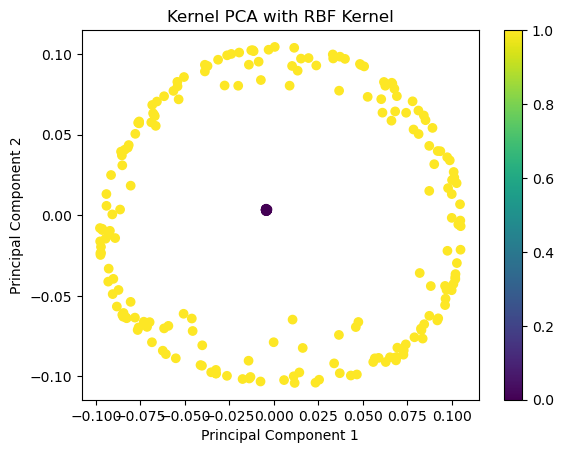

In [11]:
#Stdp 5 :Extract non linear components
X_kpca = eigenvectors[:, :2] 
# Step 6 : visualize the results
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap='viridis')
plt.title('Kernel PCA with RBF Kernel')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar()
plt.show()

#### Observations :
Inner circle points behave similarly

Outer circle points behave similarly

Inner and outer are different from each other

Kernel PCA captures that structure.

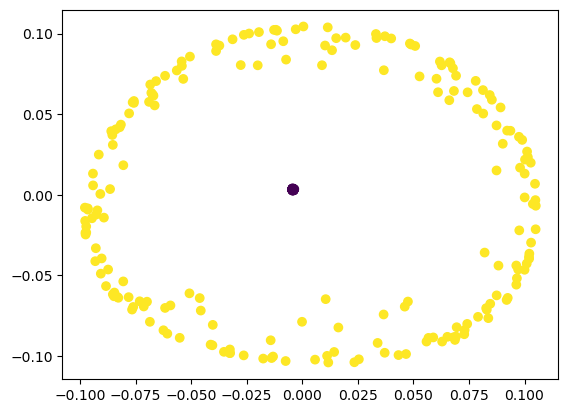

In [13]:
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y)

Kernel PCA successfully captured the nonlinear circular geometry of the data using similarity-based transformation.

## **Part 3** : The scikit-learn Way

In [12]:
from sklearn.decomposition import KernelPCA

kpca = KernelPCA(n_components =2, kernel='rbf', gamma=15)
X_kpca_sklearn = kpca.fit_transform(X)

Kernel PCA replaces dot products with similarity functions,
performs PCA in an implicit high-dimensional space,
and captures nonlinear structure.